In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlalchemy as alc
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

from nltk.sentiment import SentimentIntensityAnalyzer
from tqdm.notebook import tqdm
from transformers import AutoTokenizer
from transformers import AutoModelForSequenceClassification
from scipy.special import softmax


In [2]:
basePath = r"C:\Users\DELL\Desktop\Programming\Data analytics\work\Brazilian E-Commerce Public Dataset\Data"

In [3]:
customers = pd.read_csv(f'{basePath}\\olist_customers_dataset.csv')
orders = pd.read_csv(f'{basePath}\\olist_orders_dataset.csv')
order_items = pd.read_csv(f'{basePath}\\olist_order_items_dataset.csv')
payments = pd.read_csv(f'{basePath}\\olist_order_payments_dataset.csv')
products = pd.read_csv(f'{basePath}\\olist_products_dataset.csv')
translations = pd.read_csv(f'{basePath}\\product_category_name_translation.csv')
reviews = pd.read_csv(f'{basePath}\\olist_order_reviews_dataset.csv')
sellers = pd.read_csv(f'{basePath}\\olist_sellers_dataset.csv')

In [4]:
datasets = {
    'Customers' : customers,
    'Orders' : orders,
    'Order_Items' : order_items,
    'Payments' : payments,
    'Translations' : translations,
    'Products': products,
    'Reviews' : reviews,
    'Sellers' : sellers
}

### Checking duplicates iteratively

In [6]:
for name, df in datasets.items():
    duplicate_count = df.duplicated().sum()
    print(f"{name} Table has {duplicate_count} duplicate rows")

    if duplicate_count > 0:
        df.drop_duplicates(inplace=True)
        print(f"--> Fixed: Removed duplicates from {name} Table.")

Customers Table has 0 duplicate rows
Orders Table has 0 duplicate rows
Order_Items Table has 0 duplicate rows
Payments Table has 0 duplicate rows
Translations Table has 0 duplicate rows
Products Table has 0 duplicate rows
Reviews Table has 0 duplicate rows
Sellers Table has 0 duplicate rows


### Checking iteratively the missing values 

In [8]:
for name, df in datasets.items():
    count_null = df.isnull().sum()
    missing_columns = count_null[count_null > 0]
    
    print(f"==================== {name.upper()} TABLE MISSING VALUES ====================")

    if not missing_columns.empty:
        print(missing_columns)
    else:
        print("All columns are fine")


==================== CUSTOMERS TABLE MISSING VALUES ====================
All columns are fine
==================== ORDERS TABLE MISSING VALUES ====================
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
dtype: int64
==================== ORDER_ITEMS TABLE MISSING VALUES ====================
All columns are fine
==================== PAYMENTS TABLE MISSING VALUES ====================
All columns are fine
==================== TRANSLATIONS TABLE MISSING VALUES ====================
All columns are fine
==================== PRODUCTS TABLE MISSING VALUES ====================
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64
==================== REVIEWS TABLE MISSING VALUES ================

In [9]:
products[products.isnull()]

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...
32946,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
32947,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
32948,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
32949,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Dealing with Orders table

In [11]:
orders[orders['order_approved_at'].isnull()]

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
1130,00b1cb0320190ca0daa2c88b35206009,3532ba38a3fd242259a514ac2b6ae6b6,canceled,28/08/2018 15:26,NaN,NaN,NaN,12/09/2018 00:00
1801,ed3efbd3a87bea76c2812c66a0b32219,191984a8ba4cbb2145acb4fe35b69664,canceled,20/09/2018 13:54,NaN,NaN,NaN,17/10/2018 00:00
1868,df8282afe61008dc26c6c31011474d02,aa797b187b5466bc6925aaaa4bb3bed1,canceled,04/03/2017 12:14,NaN,NaN,NaN,10/04/2017 00:00
2029,8d4c637f1accf7a88a4555f02741e606,b1dd715db389a2077f43174e7a675d07,canceled,29/08/2018 16:27,NaN,NaN,NaN,13/09/2018 00:00
2161,7a9d4c7f9b068337875b95465330f2fc,7f71ae48074c0cfec9195f88fcbfac55,canceled,01/05/2017 16:12,NaN,NaN,NaN,30/05/2017 00:00
...,...,...,...,...,...,...,...,...
97696,5a00b4d35edffc56b825c3646a99ba9d,6a3bdf004ca96338fb5fad1b8d93c2e6,canceled,02/07/2017 15:38,NaN,NaN,NaN,25/07/2017 00:00
98415,227c804e2a44760671a6a5697ea549e4,62e7477e75e542243ee62a0ba73f410f,canceled,28/09/2017 15:02,NaN,NaN,NaN,16/10/2017 00:00
98909,e49e7ce1471b4693482d40c2bd3ad196,e4e7ab3f449aeb401f0216f86c2104db,canceled,07/08/2018 11:16,NaN,NaN,NaN,10/08/2018 00:00
99283,3a3cddda5a7c27851bd96c3313412840,0b0d6095c5555fe083844281f6b093bb,canceled,31/08/2018 16:13,NaN,NaN,NaN,01/10/2018 00:00


In [12]:
products['product_category_name'] = products['product_category_name'].fillna('Unknown')
prodColn = ['product_name_lenght', 'product_description_lenght', 'product_photos_qty', 
                    'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm']
for x in prodColn:
    products[x] = products[x].fillna(0)
    
    
print("Total missing values in Products table:", products.isnull().sum())

Total missing values in Products table: product_id                    0
product_category_name         0
product_name_lenght           0
product_description_lenght    0
product_photos_qty            0
product_weight_g              0
product_length_cm             0
product_height_cm             0
product_width_cm              0
dtype: int64


### Dealing with Review table

In [14]:
reviews

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53
...,...,...,...,...,...,...,...
99219,574ed12dd733e5fa530cfd4bbf39d7c9,2a8c23fee101d4d5662fa670396eb8da,5,NaN,NaN,2018-07-07 00:00:00,2018-07-14 17:18:30
99220,f3897127253a9592a73be9bdfdf4ed7a,22ec9f0669f784db00fa86d035cf8602,5,NaN,NaN,2017-12-09 00:00:00,2017-12-11 20:06:42
99221,b3de70c89b1510c4cd3d0649fd302472,55d4004744368f5571d1f590031933e4,5,NaN,"Excelente mochila, entrega super rápida. Super...",2018-03-22 00:00:00,2018-03-23 09:10:43
99222,1adeb9d84d72fe4e337617733eb85149,7725825d039fc1f0ceb7635e3f7d9206,4,NaN,NaN,2018-07-01 00:00:00,2018-07-02 12:59:13


In [15]:
reviews['review_comment_title'] = reviews['review_comment_title'].fillna('No title')
reviews['review_comment_message'] = reviews['review_comment_message'].fillna('No message')

print(f" Missing value for field review_comment_message :{reviews['review_comment_message'].isnull().sum()}")
print(f" Missing value for field review_comment_title :{reviews['review_comment_title'].isnull().sum()}")



 Missing value for field review_comment_message :0
 Missing value for field review_comment_title :0


In [16]:
### Reviewing each tables data type

In [17]:
datasets = {
    'Customers' : customers,
    'Orders' : orders,
    'Order_Items' : order_items,
    'Payments' : payments,
    'Translations' : translations,
    'Products': products,
    'Reviews' : reviews,
    'Sellers' : sellers
}

In [18]:
print(customers.dtypes)

customer_id                 object
customer_unique_id          object
customer_zip_code_prefix     int64
customer_city               object
customer_state              object
dtype: object


In [19]:
print(orders.dtypes)

order_id                         object
customer_id                      object
order_status                     object
order_purchase_timestamp         object
order_approved_at                object
order_delivered_carrier_date     object
order_delivered_customer_date    object
order_estimated_delivery_date    object
dtype: object


In [20]:
orders_date_type = ['order_purchase_timestamp','order_approved_at','order_delivered_carrier_date',
                   'order_delivered_customer_date','order_delivered_customer_date','order_estimated_delivery_date']

for x in orders_date_type:
    orders[x] = pd.to_datetime(orders[x],errors='coerce')

C:\Users\DELL\AppData\Local\Temp\ipykernel_18984\1444373718.py:5: UserWarning: Parsing dates in %d/%m/%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  orders[x] = pd.to_datetime(orders[x],errors='coerce')


In [21]:
print(order_items.dtypes)

order_id                object
order_item_id            int64
product_id              object
seller_id               object
shipping_limit_date     object
price                  float64
freight_value          float64
dtype: object


In [22]:
order_items['shipping_limit_date'] = pd.to_datetime(order_items['shipping_limit_date'])

In [23]:
print(payments.dtypes)

order_id                 object
payment_sequential        int64
payment_type             object
payment_installments      int64
payment_value           float64
dtype: object


In [24]:
products

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0
...,...,...,...,...,...,...,...,...,...
32946,a0b7d5a992ccda646f2d34e418fff5a0,moveis_decoracao,45.0,67.0,2.0,12300.0,40.0,40.0,40.0
32947,bf4538d88321d0fd4412a93c974510e6,construcao_ferramentas_iluminacao,41.0,971.0,1.0,1700.0,16.0,19.0,16.0
32948,9a7c6041fa9592d9d9ef6cfe62a71f8c,cama_mesa_banho,50.0,799.0,1.0,1400.0,27.0,7.0,27.0
32949,83808703fc0706a22e264b9d75f04a2e,informatica_acessorios,60.0,156.0,2.0,700.0,31.0,13.0,20.0


In [25]:
print(products.dtypes)

product_id                     object
product_category_name          object
product_name_lenght           float64
product_description_lenght    float64
product_photos_qty            float64
product_weight_g              float64
product_length_cm             float64
product_height_cm             float64
product_width_cm              float64
dtype: object


In [26]:
intType = ['product_name_lenght', 'product_description_lenght', 'product_photos_qty']

for x in intType:
    products[x] = products[x].astype('int64')

In [27]:
reviews

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,No title,No message,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,No title,No message,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,No title,No message,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,No title,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,No title,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53
...,...,...,...,...,...,...,...
99219,574ed12dd733e5fa530cfd4bbf39d7c9,2a8c23fee101d4d5662fa670396eb8da,5,No title,No message,2018-07-07 00:00:00,2018-07-14 17:18:30
99220,f3897127253a9592a73be9bdfdf4ed7a,22ec9f0669f784db00fa86d035cf8602,5,No title,No message,2017-12-09 00:00:00,2017-12-11 20:06:42
99221,b3de70c89b1510c4cd3d0649fd302472,55d4004744368f5571d1f590031933e4,5,No title,"Excelente mochila, entrega super rápida. Super...",2018-03-22 00:00:00,2018-03-23 09:10:43
99222,1adeb9d84d72fe4e337617733eb85149,7725825d039fc1f0ceb7635e3f7d9206,4,No title,No message,2018-07-01 00:00:00,2018-07-02 12:59:13


In [28]:
print(reviews.dtypes)

review_id                  object
order_id                   object
review_score                int64
review_comment_title       object
review_comment_message     object
review_creation_date       object
review_answer_timestamp    object
dtype: object


In [29]:
reviewsDate = ['review_creation_date','review_answer_timestamp']
for x in reviewsDate:
    reviews[x] = pd.to_datetime(reviews[x], errors='coerce')

### olist_geolocation_dataset is a very big file with over a million record what I'm going to is to get it reduce to its mean values of latitude and longitudes

In [31]:
geoLoc = pd.read_csv(f"{basePath}\\olist_geolocation_dataset.csv")


In [32]:
geoLoc = geoLoc.groupby('geolocation_zip_code_prefix').agg({
    'geolocation_lat':'mean',
    'geolocation_lng':'mean',
    'geolocation_city':'first',
    'geolocation_state':'first'
}).reset_index()

geoLoc.columns = ['zip_code_prefix', 'lat', 'lng', 'city', 'state']



In [33]:
geoLoc

,zip_code_prefix,lat,lng,city,state
0,1001,-23.550190,-46.634024,sao paulo,SP
1,1002,-23.548146,-46.634979,sao paulo,SP
2,1003,-23.548994,-46.635731,sao paulo,SP
3,1004,-23.549799,-46.634757,sao paulo,SP
4,1005,-23.549456,-46.636733,sao paulo,SP
...,...,...,...,...,...
19010,99960,-27.953722,-52.025511,charrua,RS
19011,99965,-28.183372,-52.039850,agua santa,RS
19012,99970,-28.343766,-51.874689,ciriaco,RS
19013,99980,-28.389129,-51.843836,david canabarro,RS


### Data ingestion to SQL Server

In [35]:
engine = alc.create_engine(r'mssql+pyodbc://DESKTOP-LEVIKVU\SQLEXPRESS/OlistBEPD?driver=ODBC+Driver+17+for+SQL+Server&Trusted_Connection=yes',fast_executemany=True)

In [36]:


# finalTables = {
#     'customers' : customers,
#     'orders' : orders,
#     'order_Items' : order_items,
#     'payments' : payments,
#     'translations' : translations,
#     'products': products,
#     'reviews' : reviews,
#     'sellers' : sellers,
#     'geoLocation' : geoLoc
# }

# print("Starting the ingestion of data in SQL server...")

# for keys, df in finalTables.items():
#     print(f"Uploading {keys} ({len(df)} rows)...")
#     df.to_sql(keys, con=engine, if_exists='replace', index=False, chunksize=10000)
#     print(f"{keys} uploaded successfully!")


# print("="*50)
# print(f"All {len(finalTables)} uploaded into OlistBEPD database")

In [37]:
# len(finalTables)

## RFM segmentation analysis of Sellers and Buyers

In [39]:
sellers

,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP
...,...,...,...,...
3090,98dddbc4601dd4443ca174359b237166,87111,sarandi,PR
3091,f8201cab383e484733266d1906e2fdfa,88137,palhoca,SC
3092,74871d19219c7d518d0090283e03c137,4650,sao paulo,SP
3093,e603cf3fec55f8697c9059638d6c8eb5,96080,pelotas,RS


### Buyers

In [41]:
order_items

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14
...,...,...,...,...,...,...,...
112645,fffc94f6ce00a00581880bf54a75a037,1,4aa6014eceb682077f9dc4bffebc05b0,b8bc237ba3788b23da09c0f1f3a3288c,2018-05-02 04:11:01,299.99,43.41
112646,fffcd46ef2263f404302a634eb57f7eb,1,32e07fd915822b0765e448c4dd74c828,f3c38ab652836d21de61fb8314b69182,2018-07-20 04:31:48,350.00,36.53
112647,fffce4705a9662cd70adb13d4a31832d,1,72a30483855e2eafc67aee5dc2560482,c3cfdc648177fdbbbb35635a37472c53,2017-10-30 17:14:25,99.90,16.95
112648,fffe18544ffabc95dfada21779c9644f,1,9c422a519119dcad7575db5af1ba540e,2b3e4a2a3ea8e01938cabda2a3e5cc79,2017-08-21 00:04:32,55.99,8.72


In [42]:
ordersFiltered = orders.dropna(subset=['order_purchase_timestamp'])

In [43]:
### Sellers

mergeRFM_sellers = ordersFiltered.merge(payments, on='order_id', how='inner')
mergeRFM_sellers = mergeRFM_sellers.merge(order_items, on='order_id', how='inner')
snapshot_date_sellers = mergeRFM_sellers['order_purchase_timestamp'].max()

rfm_sellers = mergeRFM_sellers.groupby('seller_id').agg({
    'order_purchase_timestamp': lambda x: (snapshot_date_sellers - x.max()).days,
    'order_id': 'nunique',
    'price': 'sum' 
}).rename(columns={
    'order_purchase_timestamp': 'Recency',
    'order_id': 'Frequency',
    'price': 'Monetary'
})

rfm_sellers.head()

,Recency,Frequency,Monetary
seller_id,,,
0015a82c2db000af6aaaf3ae2ecb0532,363,1,895.00
001cca7ae9ae17fb1caed9dfb1094831,1,91,11366.69
001e6ad469a905060d959994f1b41e4f,153,1,250.00
002100f778ceb8431b7a1020ff7ab48f,4,20,607.80
004c9cd9d87a3c30c522c48c4fc07416,5,69,10500.07


In [44]:
### Buyers

mergeRFM_buyers = ordersFiltered.merge(payments, on='order_id',how='inner')
mergeRFM_buyers= mergeRFM_buyers.merge(customers,on='customer_id', how='inner')

snapshot_date = mergeRFM_buyers['order_purchase_timestamp'].max()

rfm_buyers = mergeRFM_buyers.groupby('customer_unique_id').agg({
                                        'order_purchase_timestamp':lambda x: (snapshot_date-x.max()).days,
                                        'order_id':'nunique',
                                        'payment_value' : 'sum'
}).rename(columns={'order_purchase_timestamp':'Recency',
                   'order_id':'Frequency',
                   'payment_value':'Total'})

rfm_buyers.head()

,Recency,Frequency,Total
customer_unique_id,,,
0000366f3b9a7992bf8c76cfdf3221e2,65,1,141.90
0000b849f77a49e4a4ce2b2a4ca5be3f,157,1,27.19
0000f46a3911fa3c0805444483337064,431,1,86.22
0000f6ccb0745a6a4b88665a16c9f078,363,1,43.62
0004bd2a26a76fe21f786e4fbd80607f,218,1,166.98


In [45]:
scaler = StandardScaler()
scaled_rfm_buyers = scaler.fit_transform(rfm_buyers)
scaled_rfm_sellers = scaler.fit_transform(rfm_sellers)

Text(0, 0.5, 'Inertia')

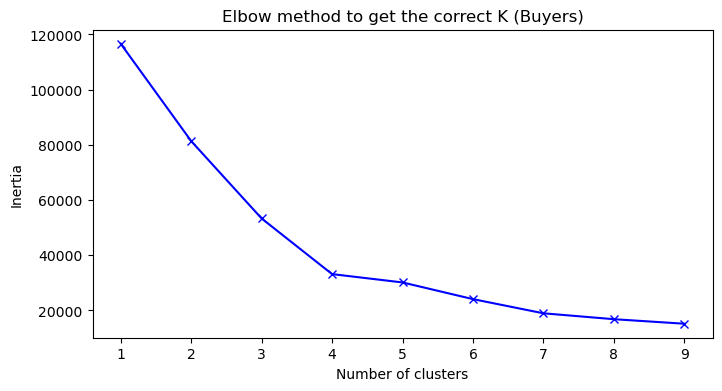

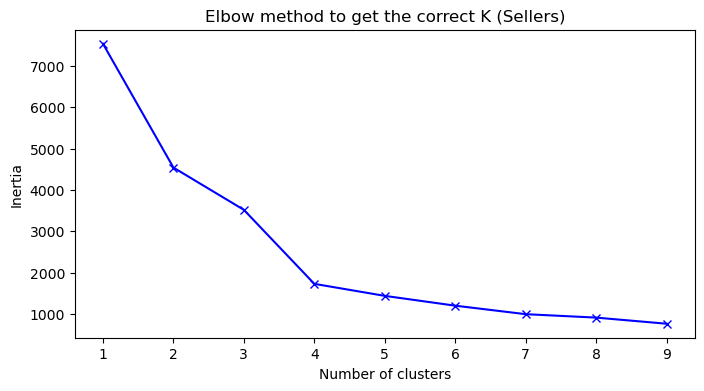

In [46]:
inertia_buyers = []
inertia_sellers = []


n = range(1,10)

for k in n:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit_predict(scaled_rfm_buyers)
    inertia_buyers.append(kmeans.inertia_)

for k in n:
    kmeans = KMeans(n_clusters=k, random_state=43)
    kmeans.fit_predict(scaled_rfm_sellers)
    inertia_sellers.append(kmeans.inertia_)



plt.figure(figsize=(8,4))
plt.plot(n, inertia_buyers, 'bx-')
plt.title('Elbow method to get the correct K (Buyers)')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')

plt.figure(figsize=(8,4))
plt.plot(n, inertia_sellers, 'bx-')
plt.title('Elbow method to get the correct K (Sellers)')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')



In [47]:
optimal_k_b = 4
optimal_k_s = 4 

real_kmean_b = KMeans(n_clusters=optimal_k_b, random_state = 43)
clusters_buyers = real_kmean_b.fit_predict(scaled_rfm_buyers)

real_kmean_s = KMeans(n_clusters=optimal_k_s, random_state = 43)
clusters_sellers = real_kmean_s.fit_predict(scaled_rfm_sellers)


In [48]:
rfm_sellers

,Recency,Frequency,Monetary
seller_id,,,
0015a82c2db000af6aaaf3ae2ecb0532,363,1,895.00
001cca7ae9ae17fb1caed9dfb1094831,1,91,11366.69
001e6ad469a905060d959994f1b41e4f,153,1,250.00
002100f778ceb8431b7a1020ff7ab48f,4,20,607.80
004c9cd9d87a3c30c522c48c4fc07416,5,69,10500.07
...,...,...,...
ffc470761de7d0232558ba5e786e57b7,34,10,704.40
ffdd9f82b9a447f6f8d4b91554cc7dd3,6,4,380.50
ffeee66ac5d5a62fe688b9d26f83f534,220,3,409.97


In [49]:
rfm_buyers['Clusters'] = clusters_buyers+1
rfm_sellers['Clusters'] = clusters_sellers+1

In [50]:
rfm_buyers

,Recency,Frequency,Total,Clusters
customer_unique_id,,,,
0000366f3b9a7992bf8c76cfdf3221e2,65,1,141.90,1
0000b849f77a49e4a4ce2b2a4ca5be3f,157,1,27.19,1
0000f46a3911fa3c0805444483337064,431,1,86.22,4
0000f6ccb0745a6a4b88665a16c9f078,363,1,43.62,4
0004bd2a26a76fe21f786e4fbd80607f,218,1,166.98,1
...,...,...,...,...
fffcf5a5ff07b0908bd4e2dbc735a684,489,1,2067.42,2
fffea47cd6d3cc0a88bd621562a9d061,422,1,84.58,4
ffff371b4d645b6ecea244b27531430a,524,1,112.46,4


In [51]:
rfm_sellers

,Recency,Frequency,Monetary,Clusters
seller_id,,,,
0015a82c2db000af6aaaf3ae2ecb0532,363,1,895.00,1
001cca7ae9ae17fb1caed9dfb1094831,1,91,11366.69,2
001e6ad469a905060d959994f1b41e4f,153,1,250.00,4
002100f778ceb8431b7a1020ff7ab48f,4,20,607.80,4
004c9cd9d87a3c30c522c48c4fc07416,5,69,10500.07,2
...,...,...,...,...
ffc470761de7d0232558ba5e786e57b7,34,10,704.40,4
ffdd9f82b9a447f6f8d4b91554cc7dd3,6,4,380.50,4
ffeee66ac5d5a62fe688b9d26f83f534,220,3,409.97,4


In [52]:
rfm_buyers.corr()


,Recency,Frequency,Total,Clusters
Recency,1.000000,-0.007657,0.000290,0.833605
Frequency,-0.007657,1.000000,0.095118,0.060017
Total,0.000290,0.095118,1.000000,-0.024619
Clusters,0.833605,0.060017,-0.024619,1.000000


In [53]:
rfm_sellers.corr()

,Recency,Frequency,Monetary,Clusters
Recency,1.000000,-0.230112,-0.212455,-0.813469
Frequency,-0.230112,1.000000,0.778383,-0.002204
Monetary,-0.212455,0.778383,1.000000,-0.013008
Clusters,-0.813469,-0.002204,-0.013008,1.000000


#### Cluster summary profile

In [55]:
clusters_summary_buyers = rfm_buyers.groupby('Clusters').mean().round(2)
clusters_summary_sellers = rfm_sellers.groupby('Clusters').mean().round(2)
print('='*10+'Clusters buyers summary'+'='*10)
print(clusters_summary_buyers)
print('\n')
print('='*10+'Clusters sellers summary'+'='*10)
print(clusters_summary_sellers)

==========Clusters buyers summary==========
          Recency  Frequency    Total
Clusters                             
1          173.05       1.00   136.19
2          342.03       1.00  1161.90
3          321.86       2.08   301.95
4          537.68       1.00   134.40


==========Clusters sellers summary==========
          Recency  Frequency  Monetary
Clusters                              
1          459.39       3.59    600.58
2           13.32     109.05  15649.10
3            1.00     415.29  66092.79
4           70.13      10.99   1502.19


## Scatterplot to visualise the segmentation

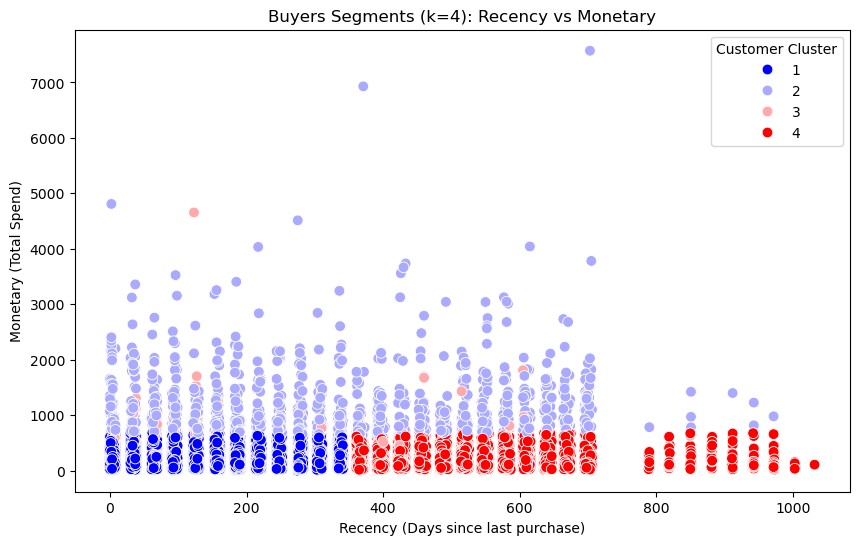

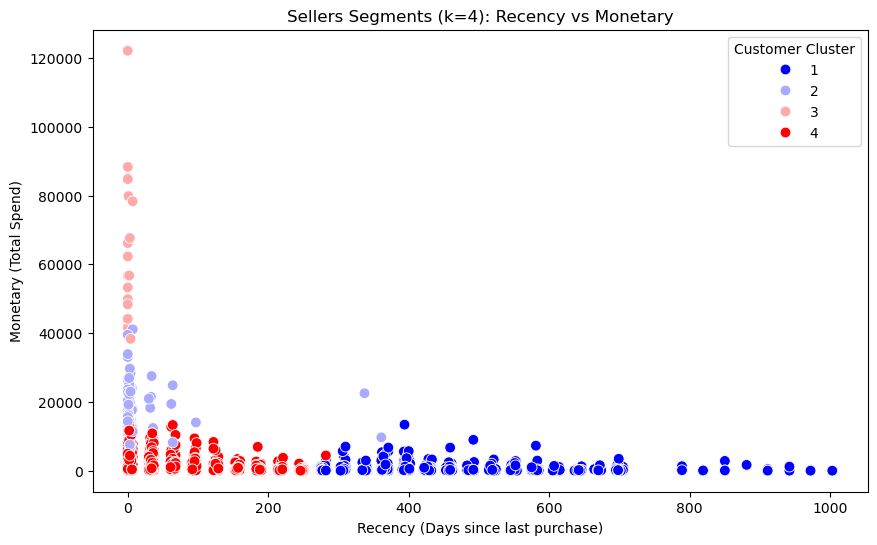

In [57]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=rfm_buyers, x='Recency', y='Total', hue='Clusters',palette='bwr',s=60)
plt.title(f'Buyers Segments (k={optimal_k_b}): Recency vs Monetary')
plt.xlabel('Recency (Days since last purchase)')
plt.ylabel('Monetary (Total Spend)')
plt.legend(title='Customer Cluster')

plt.figure(figsize=(10,6))
sns.scatterplot(data=rfm_sellers, x='Recency', y='Monetary', hue='Clusters',palette='bwr',s=60)
plt.title(f'Sellers Segments (k={optimal_k_s}): Recency vs Monetary')
plt.xlabel('Recency (Days since last purchase)')
plt.ylabel('Monetary (Total Spend)')
plt.legend(title='Customer Cluster')

In [58]:
#maping the sellers
clusters_maping_buyers= {2:'Champions',
                         1:'Top Buyers',
                         3: 'Active',
                         4: 'Lost/hibernating'}
rfm_buyers['Buyers_segment'] = rfm_buyers['Clusters'].map(clusters_maping_buyers)

In [59]:
#maping the sellers
clusters_maping_sellers= {3:'Champions',
                         4:'Top Sellers',
                         1: 'Active',
                         2: 'Lost/hibernating'}
rfm_sellers['Seller_segment'] = rfm_sellers['Clusters'].map(clusters_maping_sellers)


In [60]:
rfm_sellers

,Recency,Frequency,Monetary,Clusters,Seller_segment
seller_id,,,,,
0015a82c2db000af6aaaf3ae2ecb0532,363,1,895.00,1,Active
001cca7ae9ae17fb1caed9dfb1094831,1,91,11366.69,2,Lost/hibernating
001e6ad469a905060d959994f1b41e4f,153,1,250.00,4,Top Sellers
002100f778ceb8431b7a1020ff7ab48f,4,20,607.80,4,Top Sellers
004c9cd9d87a3c30c522c48c4fc07416,5,69,10500.07,2,Lost/hibernating
...,...,...,...,...,...
ffc470761de7d0232558ba5e786e57b7,34,10,704.40,4,Top Sellers
ffdd9f82b9a447f6f8d4b91554cc7dd3,6,4,380.50,4,Top Sellers
ffeee66ac5d5a62fe688b9d26f83f534,220,3,409.97,4,Top Sellers


In [61]:
rfm_buyers

,Recency,Frequency,Total,Clusters,Buyers_segment
customer_unique_id,,,,,
0000366f3b9a7992bf8c76cfdf3221e2,65,1,141.90,1,Top Buyers
0000b849f77a49e4a4ce2b2a4ca5be3f,157,1,27.19,1,Top Buyers
0000f46a3911fa3c0805444483337064,431,1,86.22,4,Lost/hibernating
0000f6ccb0745a6a4b88665a16c9f078,363,1,43.62,4,Lost/hibernating
0004bd2a26a76fe21f786e4fbd80607f,218,1,166.98,1,Top Buyers
...,...,...,...,...,...
fffcf5a5ff07b0908bd4e2dbc735a684,489,1,2067.42,2,Champions
fffea47cd6d3cc0a88bd621562a9d061,422,1,84.58,4,Lost/hibernating
ffff371b4d645b6ecea244b27531430a,524,1,112.46,4,Lost/hibernating


### Save the results of the both buyers and sellers RFM as CSV files to feed into Power BI

In [63]:
rfm_buyers.to_csv(r"C:\Users\DELL\Desktop\Programming\Data analytics\work\Brazilian E-Commerce Public Dataset\Data\rfm_buyers.csv")
rfm_sellers.to_csv(r"C:\Users\DELL\Desktop\Programming\Data analytics\work\Brazilian E-Commerce Public Dataset\Data\rfm_sellers.csv")

## Sentimental Analysis with Roberta

In [155]:
rev_sent

,review_id,review_id,review_comment_message
63339,5c557dc1f955add7889f4e01ad0efd4b,5c557dc1f955add7889f4e01ad0efd4b,Nota 10
98349,70a2ba97adb4440ac268fba6b8d340d5,70a2ba97adb4440ac268fba6b8d340d5,No message
84778,b4b4af625928af742f2a27e1fb3e776c,b4b4af625928af742f2a27e1fb3e776c,No message
72598,dee9554edc5fbdcd60b601e2829e5062,dee9554edc5fbdcd60b601e2829e5062,Bom
38331,1dc2a65166710926ba671c7eb117aa44,1dc2a65166710926ba671c7eb117aa44,mundo eficiente loja 100º
...,...,...,...
35204,5e5e2785f16f019d70dee2f95e82352c,5e5e2785f16f019d70dee2f95e82352c,No message
11239,25c8204e4c78a080e76ef2b2b03fc7d3,25c8204e4c78a080e76ef2b2b03fc7d3,No message
81570,4f51cac79915ec9cdca1b6dff30f65c9,4f51cac79915ec9cdca1b6dff30f65c9,No message
15217,e7db6831ef1c2ba3439cf3ddcd1513d8,e7db6831ef1c2ba3439cf3ddcd1513d8,otimo produto


In [148]:
rev_sent = reviews.sample(10000)

In [150]:
from transformers import pipeline
from tqdm.notebook import tqdm
rev_sent = rev_sent[['review_id','review_id','review_comment_message']]
rev_sent = rev_sent.dropna(subset='review_comment_message')

In [157]:
save_path = r"C:\Users\DELL\Desktop\Programming\Data analytics\work\Brazilian E-Commerce Public Dataset\Data\olist_reviews_sentiment.csv"

sentiment_analyzer = pipeline("sentiment-analysis", model="nlptown/bert-base-multilingual-uncased-sentiment")
print("Running Sentiment Analysis on Portuguese reviews...")

stars = []
confidence_scores = []

for index, row in tqdm(rev_sent.iterrows(), total=len(rev_sent)):
    text = str(row['review_comment_message']).strip()
    
    if text == "" or text.lower() == "nan" or text == "No message given":
        stars.append("No Review")
        confidence_scores.append(0.0)
        continue 
    
    text = text[:512] 
    
    try:
        result = sentiment_analyzer(text)[0]
        stars.append(result['label'])
        confidence_scores.append(result['score'])
        
    except Exception as e:
        print(f"Error on review {row['review_id']}: {e}")
        stars.append("Error")
        confidence_scores.append(0.0)

rev_sent['Predicted_Stars'] = stars
rev_sent['Confidence_Score'] = confidence_scores

rev_sent.to_csv(save_path, index=False, encoding='utf-8-sig')
print(f"Success! Data saved to {save_path}")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Running Sentiment Analysis on Portuguese reviews...


  0%|          | 0/10000 [00:00<?, ?it/s]

Success! Data saved to C:\Users\DELL\Desktop\Programming\Data analytics\work\Brazilian E-Commerce Public Dataset\Data\olist_reviews_sentiment.csv
